In [2]:
# Imports
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from mpl_toolkits.mplot3d import Axes3D

Y = X^2

In [2]:
# Generate Data
x = np.linspace(-10, 10, 1000)
y = x ** 2

# Reshape for Keras (expects 2D inputs)
x = x.reshape(-1, 1)
y = y.reshape(-1, 1)

In [ ]:
# Train Test Split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [ ]:
# Build Model - Functional API
inputs = Input(shape=(1,))
x_dense = Dense(64, activation='relu')(inputs)
x_dense = Dense(64, activation='relu')(x_dense)
outputs = Dense(1)(x_dense)  # Linear output for regression

model = Model(inputs=inputs, outputs=outputs)
model.compile(optimizer='adam', loss='mse')

In [5]:
# Train
history = model.fit(x_train, y_train, epochs=100, batch_size=32, validation_split=0.1)

Epoch 1/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 1961.2332 - val_loss: 1504.3838
Epoch 2/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1771.3973 - val_loss: 1250.6136
Epoch 3/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1584.8237 - val_loss: 916.2414
Epoch 4/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1028.3512 - val_loss: 536.6926
Epoch 5/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 601.0302 - val_loss: 240.9046
Epoch 6/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 273.8044 - val_loss: 154.1364
Epoch 7/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 171.1059 - val_loss: 149.4058
Epoch 8/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 154.2337 - val_loss: 144.6389
Epoch 9/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 153.9228 - val_loss: 139.9175
Epoch 10/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 151.1680 - val_loss: 135.1182
Epoch 11/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 145.6540 - val_loss: 131.0556
Epoch 12/100


In [6]:
# Evaluate
mse = model.evaluate(x_test, y_test)
print(f"Test MSE: {mse:.4f}")
y_pred = model.predict(x_test)
r2 = r2_score(y_test[:, 0], y_pred[:, 0])

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.7560 
Test MSE: 0.7079
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 774us/step


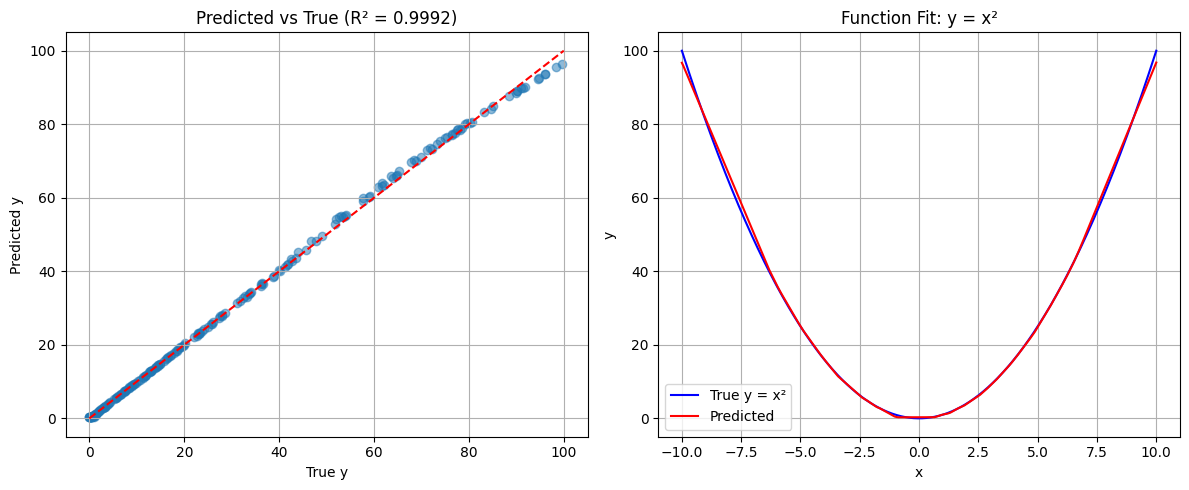

In [ ]:
# Plot
plt.figure(figsize=(12, 5))

# R2 Scatter Plot
plt.subplot(1, 2, 1)
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([0, 100], [0, 100], 'r--')
plt.xlabel("True y")
plt.ylabel("Predicted y")
plt.title(f"Predicted vs True (R² = {r2:.4f})")
plt.grid(True)

# True Curve vs Predicted Curve
x_full = np.linspace(-10, 10, 1000).reshape(-1, 1)
y_true_full = x_full ** 2
y_pred_full = model.predict(x_full)

plt.subplot(1, 2, 2)
plt.plot(x_full, y_true_full, label='True y = x²', color='blue')
plt.plot(x_full, y_pred_full, label='Predicted', color='red')
plt.xlabel("x")
plt.ylabel("y")
plt.title("Function Fit: y = x²")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

y1= x1-x2; y2= x1+x2

In [ ]:
# Generate Data
num_samples = 10000
x1 = np.random.uniform(-10, 10, num_samples)
x2 = np.random.uniform(-10, 10, num_samples)

X = np.stack([x1, x2], axis=1)  # shape (num_samples, 2)
y1 = x1 - x2
y2 = x1 + x2
Y = np.stack([y1, y2], axis=1)  # shape (num_samples, 2)

In [4]:
# Train Test Split
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

In [10]:
# Build Model
inputs = Input(shape=(2,))
x = Dense(2, activation='linear')(inputs)# 2 outputs for y1 and y2

model = Model(inputs=inputs, outputs=x)
model.compile(optimizer='adam', loss='mse')

In [11]:
# Train
history = model.fit(X_train, Y_train, epochs=30, batch_size=32, validation_split=0.1)

Epoch 1/30
225/225 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 38.6516 - val_loss: 28.1427
Epoch 2/30
225/225 ━━━━━━━━━━━━━━━━━━━━ 0s 838us/step - loss: 25.8330 - val_loss: 18.9941
Epoch 3/30
225/225 ━━━━━━━━━━━━━━━━━━━━ 0s 877us/step - loss: 17.3498 - val_loss: 12.7644
Epoch 4/30
225/225 ━━━━━━━━━━━━━━━━━━━━ 0s 835us/step - loss: 11.7148 - val_loss: 8.3948
Epoch 5/30
225/225 ━━━━━━━━━━━━━━━━━━━━ 0s 828us/step - loss: 7.7289 - val_loss: 5.3221
Epoch 6/30
225/225 ━━━━━━━━━━━━━━━━━━━━ 0s 825us/step - loss: 4.8097 - val_loss: 3.2136
Epoch 7/30
225/225 ━━━━━━━━━━━━━━━━━━━━ 0s 845us/step - loss: 2.8632 - val_loss: 1.8262
Epoch 8/30
225/225 ━━━━━━━━━━━━━━━━━━━━ 0s 842us/step - loss: 1.5924 - val_loss: 0.9708
Epoch 9/30
225/225 ━━━━━━━━━━━━━━━━━━━━ 0s 817us/step - loss: 0.8496 - val_loss: 0.4767
Epoch 10/30
225/225 ━━━━━━━━━━━━━━━━━━━━ 0s 827us/step - loss: 0.4059 - val_loss: 0.2137
Epoch 11/30
225/225 ━━━━━━━━━━━━━━━━━━━━ 0s 903us/step - loss: 0.1811 - val_loss: 0.0862
Epoch 12/30
225/225 ━━━━━

In [12]:
# Predict and Evaluate
Y_pred = model.predict(X_test)
r2_y1 = r2_score(Y_test[:, 0], Y_pred[:, 0])
r2_y2 = r2_score(Y_test[:, 1], Y_pred[:, 1])

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 656us/step


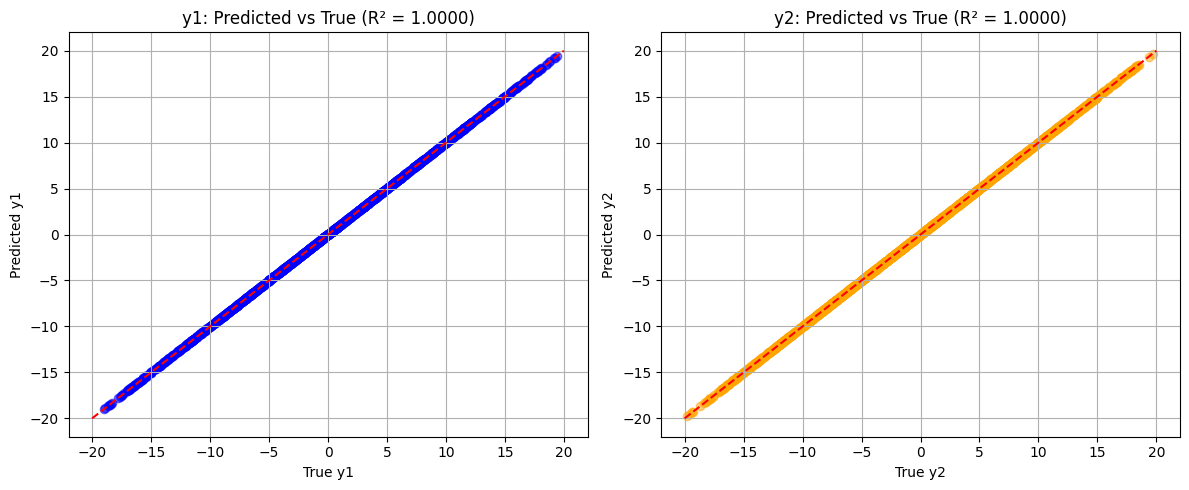

In [13]:
# R2 Scatter Plots (Separate)
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(Y_test[:, 0], Y_pred[:, 0], alpha=0.5, color='blue')
plt.plot([-20, 20], [-20, 20], 'r--')
plt.title(f"y1: Predicted vs True (R² = {r2_y1:.4f})")
plt.xlabel("True y1")
plt.ylabel("Predicted y1")
plt.grid(True)

plt.subplot(1, 2, 2)
plt.scatter(Y_test[:, 1], Y_pred[:, 1], alpha=0.5, color='orange')
plt.plot([-20, 20], [-20, 20], 'r--')
plt.title(f"y2: Predicted vs True (R² = {r2_y2:.4f})")
plt.xlabel("True y2")
plt.ylabel("Predicted y2")
plt.grid(True)

plt.tight_layout()
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 394us/step


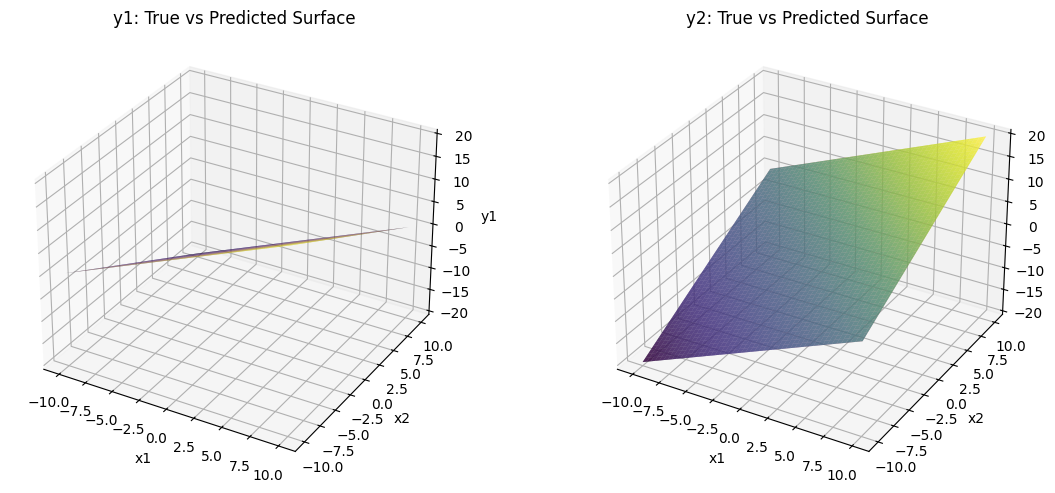

In [ ]:
# 3D Surface Comparison — True vs Predicted (for y1 and y2 separately)

# Create a grid for plotting
grid_x1 = np.linspace(-10, 10, 100)
grid_x2 = np.linspace(-10, 10, 100)
gx1, gx2 = np.meshgrid(grid_x1, grid_x2)
grid_input = np.stack([gx1.ravel(), gx2.ravel()], axis=1)
grid_pred = model.predict(grid_input)
grid_y1_pred = grid_pred[:, 0].reshape(gx1.shape)
grid_y2_pred = grid_pred[:, 1].reshape(gx1.shape)

# True functions
grid_y1_true = gx1 - gx2
grid_y2_true = gx1 + gx2

# Surface plot for y1
fig = plt.figure(figsize=(12, 5))
ax = fig.add_subplot(121, projection='3d')
ax.plot_surface(gx1, gx2, grid_y1_true, cmap='viridis', alpha=0.6, label='True')
ax.plot_surface(gx1, gx2, grid_y1_pred, cmap='inferno', alpha=0.6)
ax.set_title("y1: True vs Predicted Surface")
ax.set_xlabel("x1")
ax.set_ylabel("x2")
ax.set_zlabel("y1")

# Surface plot for y2
ax = fig.add_subplot(122, projection='3d')
ax.plot_surface(gx1, gx2, grid_y2_true, cmap='viridis', alpha=0.6, label='True')
ax.plot_surface(gx1, gx2, grid_y2_pred, cmap='inferno', alpha=0.6)
ax.set_title("y2: True vs Predicted Surface")
ax.set_xlabel("x1")
ax.set_ylabel("x2")
ax.set_zlabel("y2")

plt.tight_layout()
plt.show()